# **Complete repository step-by-step diagnostics. (Core Modules)**

This notebook serves as the authoritative validation harness and reasoning log for the core spatial and transit modules of the project. 
All tests are routed through a central helper to maintain clean execution logs:
`validate_call(label, expected_valid, func, *args, **kwargs)`: Captures exceptions and reports styled `[VALIDATED]`, `[REJECTED]`, or `[FALSE POSITIVE]` results based on expected outcomes.

### Core Diagnostic Coverage

1. **Node (`utils/node.py`)**

- Validity Checks: Enforces that lon is between -180 and 180, and lat is between -90 and 90.
-Layer Constraints: Verifies that layers must be integers from 0 to 3, or None.
- Contract Enforcement: Confirms that Node IDs are unique strings starting with "N" and that coordinate attributes are strictly immutable after creation.
- Visualization: Validates the draw method and asserts that the resulting bounding-box rendering is a square image.

2. **DirEdge (`utils/directed_edge.py`)**
- Geomery & Topology: Tests that start and end nodes cannot be identical.
- Layer Logic: Validates same-layer edges and ensures that cross-layer edges (like boarding/alighting) share exact coordinates.
- Graph Stitching: Validates the _stitch helper, ensuring that edges properly populate their next_edges lists based on coordinate-layer matching.
- Visualization: Confirms that directed edges draw correctly on the square base image.

3. **CityGraph (`utils/city_graph.py`)**
- Input Validation: Rejects malformed bounding boxes (requires exactly 4 floats).
- Graph Construction: Tests loading specific road networks (using a toy subset of Iligan City) to ensure nodes and edges populate correctly without exploding memory.
- Search & Render: Validates full network rendering and filtering for drivable (arterial) edges.
4. **DirectDemandSampler (`utils/direct_demand_sampler.py`)**
- API Verification: Checks for the mandatory presence of the TOMTOM_API_KEY in the environment.
- Heatmap Generation: Validates that the sampler correctly blends traffic data and centrality to generate an $O(1)$ sampling table (Walker alias table).
- Visualization: Overlays a density heatmap (blue/yellow/red spectrum) onto the city graph to verify spatial demand distribution.
5. **Route (`utils/route.py`)**
- Loop Integrity: Tests that routes must form closed loops.
- Contiguity: Rejects paths where edge sequences are broken or non-continuous.
- Layer Restrictiveness: Strictly requires all edges in a route to belong to Layer 2 (the transit ride layer).
- Branching Checks: Enforces a deterministic pathing rule where each node has exactly one outgoing Layer 2 edge in the route.

_**Key Takeaway.**_ If a core class is modified (e.g., adding properties to a Node or changing how Route calculates weight), this notebook must be run to ensure the core spatial contracts and edge-stitching logics are not broken.

In [1]:
from typing import Any, Callable, Optional
from rich import print
import yaml
from PIL import Image

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result

def assert_true(condition: bool, message: str) -> bool:
    if not condition:
        raise AssertionError(message)
    return True

def set_layer(edge: Any, layer: int) -> Any:
    setattr(edge, "layer", layer)
    return edge

def assert_square_image(image: Image.Image) -> bool:
    return assert_true(image.width == image.height, "Image must be square.")

def load_yaml_config(path: str) -> Any:
    with open(path, "r", encoding="utf-8") as file:
        return yaml.safe_load(file)


## **Node** (in node.py)

[VALIDATED] Node(124.2, 8.2, 0): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 1): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 2): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 3): Executed successfully.

[VALIDATED] Node(124.2, 8.2, None): Executed successfully.

...

[REJECTED] Node(124.2, 91, 0): Safely blocked with ValueError([NODE] Invalid lat value 91. Must be a number from 
-90 to 90.)

[REJECTED] Node(124.2, -91, 0): Safely blocked with ValueError([NODE] Invalid lat value -91. Must be a number from 
-90 to 90.)

[VALIDATED] Node identity and immutability: Executed successfully.

[VALIDATED] Node visualization square image: Executed successfully.

[VALIDATED] Node square check: Executed successfully.

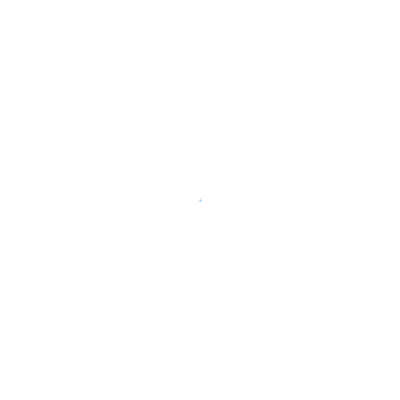

In [2]:
from utils.node import Node
from IPython.display import display

node_cases = [
    (124.2, 8.2, 0, True),
    (124.2, 8.2, 1, True),
    (124.2, 8.2, 2, True),
    (124.2, 8.2, 3, True),
    (124.2, 8.2, None, True),
]

for lon, lat, layer, expected in node_cases:
    label = f"Node({lon}, {lat}, {layer})"
    if layer is None:
        validate_call(label, expected, Node, lon, lat)
    else:
        validate_call(label, expected, Node, lon, lat, layer)

for lon, lat, layer in [(124.2, 8.2, 4), (124.2, 8.2, -1)]:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

for lon, lat, layer in [(181, 8.2, 0), (-181, 8.2, 0), (124.2, 91, 0), (124.2, -91, 0)]:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

def verify_node_contract() -> bool:
    n1 = Node(124.2, 8.2, 0)
    n2 = Node(124.2, 8.2, 0)

    assert_true(n1.id != n2.id, "Node IDs should be unique")
    assert_true(isinstance(n1.id, str) and n1.id.startswith("N"), "Node ID should be a string")
    assert_true(n1.lon == 124.2 and n1.lat == 8.2, "Node coordinates should be preserved")

    try:
        n1.lon = 125.0
        raise AssertionError("Node.lon should be immutable")
    except AttributeError:
        pass

    return True

validate_call("Node identity and immutability", True, verify_node_contract)

img = validate_call("Node visualization square image", True, lambda: Node(124.2, 8.2).draw(((124.1, 8.3), (124.3, 8.1)), Image.new("RGB", (400, 400), "white")))
if img:
    validate_call("Node square check", True, assert_square_image, img)
    display(img)


## **DirEdge** (in directed_edge.py)

[VALIDATED] DirEdge L1 same-layer: Executed successfully.

[VALIDATED] DirEdge L2 same-layer: Executed successfully.

[VALIDATED] DirEdge cross-layer 1->2: Executed successfully.

[REJECTED] DirEdge identical nodes: Safely blocked with ValueError([DIR EDGE] Start and end nodes cannot be 
identical.)

[REJECTED] DirEdge cross-layer diff coords: Safely blocked with ValueError([DIR EDGE] Start and end nodes on 
different layers must have same coordinates.)

...

[REJECTED] DirEdge None end: Safely blocked with ValueError([DIR EDGE] No end node provided.)

[REJECTED] DirEdge None both: Safely blocked with ValueError([DIR EDGE] No start and end node provided.)

[VALIDATED] Stitch populates next_edges: Executed successfully.

[VALIDATED] DirEdge draw: Executed successfully.

[VALIDATED] DirEdge square check: Executed successfully.

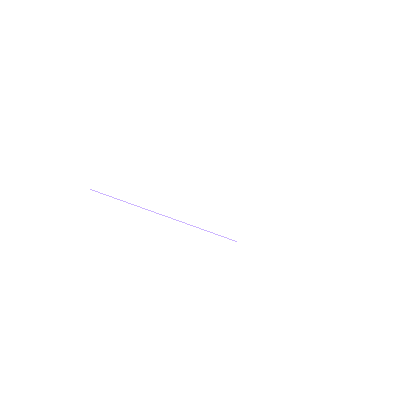

In [3]:
from utils.node import Node
from utils.directed_edge import DirEdge, _stitch
from IPython.display import display

n1l1 = Node(124.2384, 8.2393, 1)
n2l1 = Node(124.243862, 8.237768, 1)
n3l1 = Node(124.238, 8.239, 1)
n1l2 = Node(124.2384, 8.2393, 2)
n2l2 = Node(124.243862, 8.237768, 2)

# ── Positive: Valid same-layer edges
validate_call("DirEdge L1 same-layer", True, DirEdge, n1l1, n2l1)
validate_call("DirEdge L2 same-layer", True, DirEdge, n1l2, n2l2)

# ── Positive: Valid cross-layer (same coords, adjacent layers)
validate_call("DirEdge cross-layer 1->2", True, DirEdge, n1l1, n1l2)

# ── Negative: Identical nodes
validate_call("DirEdge identical nodes", False, DirEdge, n1l1, n1l1)

# ── Negative: Cross-layer with different coordinates (teleport)
validate_call("DirEdge cross-layer diff coords", False, DirEdge, n1l1, n2l2)

# ── Negative: None inputs
validate_call("DirEdge None start", False, DirEdge, None, n2l1)
validate_call("DirEdge None end", False, DirEdge, n1l1, None)
validate_call("DirEdge None both", False, DirEdge, None, None)

# ── Stitch test
e1 = DirEdge(n1l1, n2l1)
e2 = DirEdge(n2l1, n3l1)
e3 = DirEdge(n3l1, n1l1)
_stitch([e1, e2, e3], [e1, e2, e3])
validate_call("Stitch populates next_edges", True, assert_true, len(e1.next_edges) > 0, "next_edges should not be empty after stitch.")

# ── Visualization
ctx = ((124.235, 8.245), (124.25, 8.233))
base = Image.new("RGB", (400, 400), "white")
img = validate_call("DirEdge draw", True, e1.draw, ctx, base)
if img:
    validate_call("DirEdge square check", True, assert_square_image, img)
    display(img)


## **CityGraph** (in city_graph.py)

[REJECTED] BBOX Validation (Too Short): Safely blocked with ValueError([CITY GRAPH] Invalid bbox. Must be a tuple 
of 4 floats: (min_lat, max_lat, min_lon, max_lon).)

c:\Users\lifei\OneDrive\Desktop\Portfolio\Jeepney-Route-System-Optimization\.venv\Lib\site-packages\pyrosm\pyrosm.py:109: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  nodes, ways, relations, node_coordinates = parse_osm_data(
c:\Users\lifei\OneDrive\Desktop\Portfolio\Jeepney-Route-System-Optimization\.venv\Lib\site-packages\pyrosm\pyrosm.py:109: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never wo

[VALIDATED] CityGraph Toy Init (Iligan subset): Executed successfully.

[VALIDATED] Node count > 0: Executed successfully.

[VALIDATED] Edge count > 0: Executed successfully.

[VALIDATED] CityGraph draw: Executed successfully.

[VALIDATED] CityGraph square check: Executed successfully.

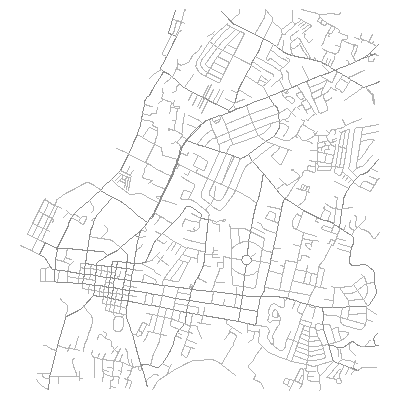

In [4]:
from utils.city_graph import CityGraph
from utils.node import Node
from utils.directed_edge import DirEdge
from IPython.display import display

# ── Negative: Invalid bbox
validate_call("BBOX Validation (Too Short)", False, CityGraph, bbox=(8.2,))

# ── Positive: Toy graph for unit-level contract testing
MOCK_BBOX = (8.22, 8.25, 124.23, 124.26)
LOCAL_PBF_PATH = "utils/data/iligan-city.pbf"

cg = validate_call(
    "CityGraph Toy Init (Iligan subset)",
    True, 
    CityGraph,
    bbox=MOCK_BBOX, 
    name="Iligan Subset", 
    pbf_path=LOCAL_PBF_PATH,
    cache_dir="utils/.cache",
    cache_prefix="test_iligan_subset"
)

if cg:
    validate_call("Node count > 0", True, assert_true, len(cg.nodes) > 0, "Graph has no nodes.")
    validate_call("Edge count > 0", True, assert_true, len(cg.graph) > 0, "Graph has no edges.")
    
    img = validate_call("CityGraph draw", True, cg.draw, size=400)
    if img:
        validate_call("CityGraph square check", True, assert_square_image, img)
        display(img)

[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 97321.84it/s] 


[VALIDATED] Iligan CityGraph Initialization: Executed successfully.

[VALIDATED] Iligan All Edges: Executed successfully.

[VALIDATED] Iligan Drivable Only: Executed successfully.

[VALIDATED] All Edges square check: Executed successfully.

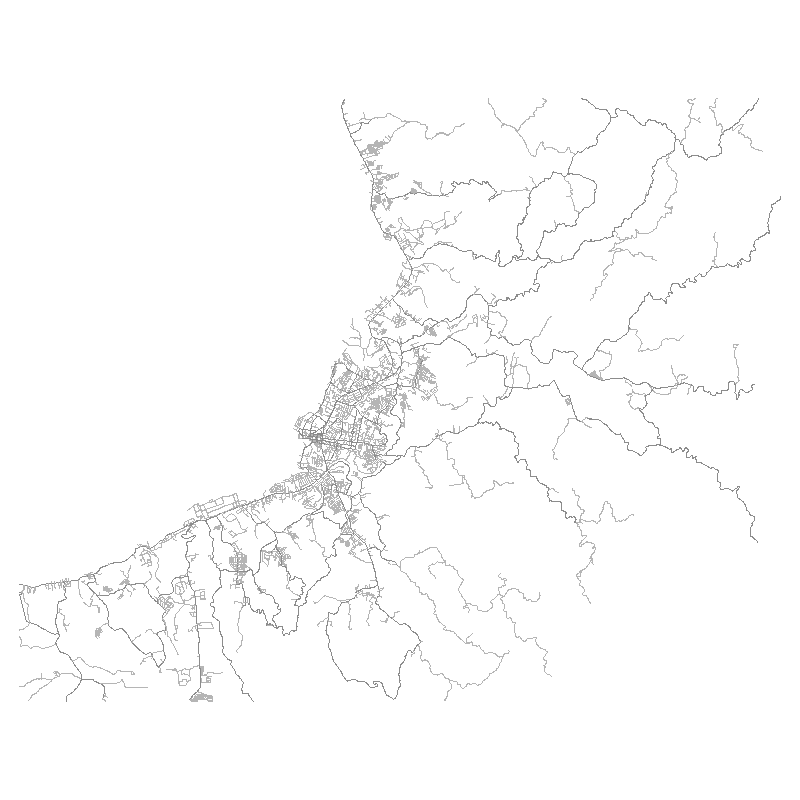

[VALIDATED] Drivable Only square check: Executed successfully.

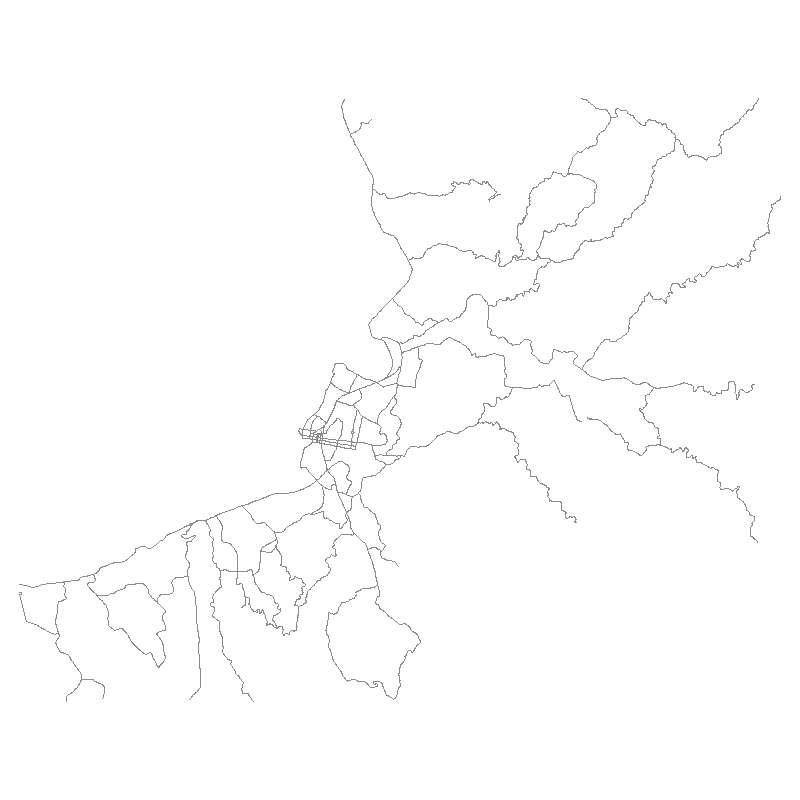

In [5]:
from IPython.display import display

cfg = load_yaml_config("configs/iligan_configs.yaml")
global_cfg = cfg["global"]
city_graph_cfg = cfg["city_graph"]

city = validate_call(
    "Iligan CityGraph Initialization",
    True,
    CityGraph,
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg.get("landmarks"),
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    verbose=True,
    cache_dir=global_cfg["cache_dir"],
    cache_prefix=city_graph_cfg["cache_prefix"]
)

if city:
    all_img = validate_call("Iligan All Edges", True, city.draw, size=800, only_drivable=False)
    drv_img = validate_call("Iligan Drivable Only", True, city.draw, size=800, only_drivable=True)
    
    if all_img:
        validate_call("All Edges square check", True, assert_square_image, all_img)
        display(all_img)
    if drv_img:
        validate_call("Drivable Only square check", True, assert_square_image, drv_img)
        display(drv_img)

In [6]:
# test reusability

import os
import time

# Verify the binary cache file was physically written to disk
cache_file_path = cg._graph_cache_path
validate_call(
    "Cache file exists on disk", 
    True, 
    assert_true, 
    os.path.exists(cache_file_path), 
    f"Cache file missing: {cache_file_path}"
)

# Initialize a new graph. 
# The invalid PBF path guarantees a crash if the cache is missed.
start_time = time.time()
cg_cached = validate_call(
    "CityGraph Cached Initialization",
    True,
    CityGraph,
    bbox=MOCK_BBOX,
    name="Iligan Subset",
    pbf_path="invalid/path/that/forces/crash/if/cache/misses.pbf",
    use_api=False,
    verbose=True,
    cache_dir="utils/.cache",
    cache_prefix="test_iligan_subset"
)
load_time = time.time() - start_time

# Validate structural parity between the original and cached graphs
if cg_cached:
    validate_call(
        "Node count parity", 
        True, 
        assert_true, 
        len(cg_cached.nodes) == len(cg.nodes), 
        "Node counts differ."
    )
    validate_call(
        "Edge count parity", 
        True, 
        assert_true, 
        len(cg_cached.graph) == len(cg.graph), 
        "Edge counts differ."
    )
    print(f"Cache verified. Loaded from binary in {load_time:.4f} seconds.")

[VALIDATED] Cache file exists on disk: Executed successfully.

[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 8440/8440 [00:00<00:00, 144763.07it/s]


[VALIDATED] CityGraph Cached Initialization: Executed successfully.

[VALIDATED] Node count parity: Executed successfully.

[VALIDATED] Edge count parity: Executed successfully.

Cache verified. Loaded from binary in 0.6327 seconds.

## **DirectDemandSampler** (in direct_demand_sampler.py)

[VALIDATED] TOMTOM API key present: Executed successfully.

[DIRECT DEMAND] Loaded sampler cache from .cache\ddm_models\8c2fb745e936c5c4b00ffae79ece7e3c.pkl.

[VALIDATED] Initialize DDM Sampler: Executed successfully.

[VALIDATED] Generate guaranteed drivable point: Executed successfully.

[VALIDATED] Verify point is in drivable set: Executed successfully.

[VALIDATED] Base map (All): Executed successfully.

[VALIDATED] Base map (Drivable): Executed successfully.

[VALIDATED] Iligan bounding context: Executed successfully.

[GLOBAL DDM PROBABILITY DISTRIBUTION]

[VALIDATED] Draw heatmap (All): Executed successfully.

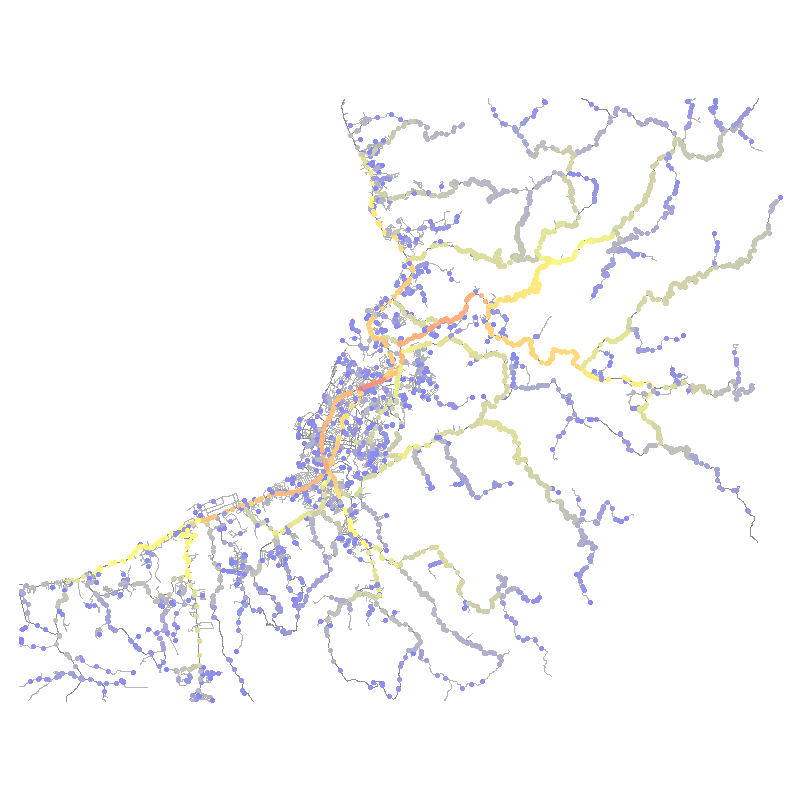

[DRIVABLE-RESTRICTED DDM PROBABILITY DISTRIBUTION]

[VALIDATED] Draw heatmap (Drivable): Executed successfully.

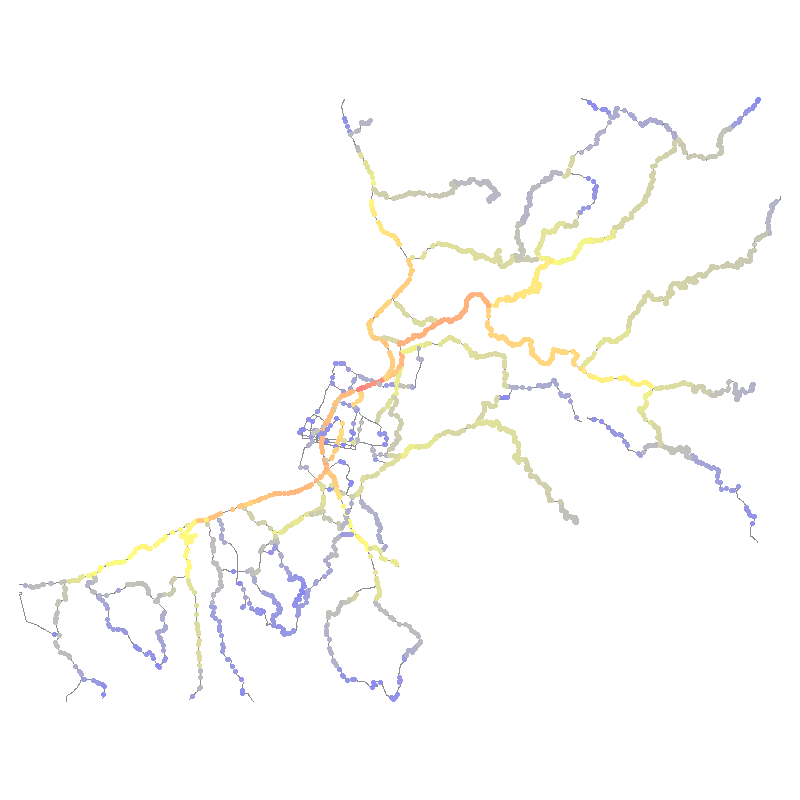

In [7]:
import os
from dotenv import load_dotenv
from IPython.display import display
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

if not TOMTOM_API_KEY:
    raise ValueError("[ENVIRONMENT] TOMTOM_API_KEY is missing from the .env file.")
else:
    validate_call("TOMTOM API key present", True, lambda: bool(TOMTOM_API_KEY))

if city and cfg:
    ddm_params = cfg["ddm"].copy()
    ddm_params["cache_dir"] = cfg["global"]["cache_dir"]

    sampler = validate_call(
        "Initialize DDM Sampler",
        True,
        DirectDemandSampler,
        city=city,
        config=DDMConfig(**ddm_params),
        verbose=True
    )

    if sampler:
        drivable_point = validate_call(
            "Generate guaranteed drivable point", 
            True, 
            sampler.get_point, 
            only_drivable=True
        )
        if drivable_point:
            validate_call(
                "Verify point is in drivable set",
                True,
                assert_true,
                drivable_point in sampler.drivable_nodes,
                "Sampled point is not drivable."
            )

        # ── DDM density visualization (Dual output)
        base_img_all = validate_call("Base map (All)", True, city.draw, size=800, only_drivable=False)
        base_img_drv = validate_call("Base map (Drivable)", True, city.draw, size=800, only_drivable=True)
        context = validate_call("Iligan bounding context", True, city.get_bounds)
        
        if context:
            if base_img_all:
                print("\n[GLOBAL DDM PROBABILITY DISTRIBUTION]")
                density_img_all = base_img_all.copy().convert("RGBA")
                validate_call("Draw heatmap (All)", True, sampler.draw_density, density_img_all, context, only_drivable=False)
                display(density_img_all)

            if base_img_drv:
                print("\n[DRIVABLE-RESTRICTED DDM PROBABILITY DISTRIBUTION]")
                density_img_drv = base_img_drv.copy().convert("RGBA")
                validate_call("Draw heatmap (Drivable)", True, sampler.draw_density, density_img_drv, context, only_drivable=True)
                display(density_img_drv)

In [8]:
# test reusability of DDM cache

import time
import utils.direct_demand_sampler as ddm_module

# Verify the DDM cache file was physically written to disk
ddm_cache_path = sampler._cache_path
validate_call(
    "DDM Cache file exists on disk", 
    True, 
    assert_true, 
    os.path.exists(ddm_cache_path), 
    f"Cache file missing: {ddm_cache_path}"
)

# Temporarily remove the API key from the module namespace. 
# This guarantees a crash if the constructor attempts to initialize the TrafficClient.
original_api_key = ddm_module.TOMTOM_API_KEY
ddm_module.TOMTOM_API_KEY = None

start_time = time.time()
sampler_cached = validate_call(
    "DDM Sampler Cached Initialization",
    True,
    DirectDemandSampler,
    city=city,
    config=DDMConfig(**ddm_params),
    verbose=True
)
load_time = time.time() - start_time

# Restore the API key to preserve testing environment integrity
ddm_module.TOMTOM_API_KEY = original_api_key

# Validate structural parity between original and cached samplers
if sampler_cached:
    validate_call(
        "Probability map parity", 
        True, 
        assert_true, 
        len(sampler_cached.node_probabilities) == len(sampler.node_probabilities), 
        "Probability distributions differ."
    )
    validate_call(
        "Alias table parity", 
        True, 
        assert_true, 
        len(sampler_cached.alias) == len(sampler.alias), 
        "Alias table sizes differ."
    )
    print(f"DDM Cache verified. Loaded from binary in {load_time:.4f} seconds.")

[VALIDATED] DDM Cache file exists on disk: Executed successfully.

[DIRECT DEMAND] Loaded sampler cache from .cache\ddm_models\8c2fb745e936c5c4b00ffae79ece7e3c.pkl.

[VALIDATED] DDM Sampler Cached Initialization: Executed successfully.

[VALIDATED] Probability map parity: Executed successfully.

[VALIDATED] Alias table parity: Executed successfully.

DDM Cache verified. Loaded from binary in 0.6542 seconds.

## **Route** (in route.py)

In [9]:
import copy
from utils.node import Node
from utils.directed_edge import DirEdge
from utils.route import Route, RouteGenerator
from IPython.display import display

# ── Route primitive contract tests (toy data, since Route is a primitive like Node/DirEdge)
class MockCityGraph:
    pass

mock_cg = MockCityGraph()

n1 = Node(124.2, 8.2, 2)
n2 = Node(124.3, 8.2, 2)
n3 = Node(124.3, 8.3, 2)
n4 = Node(124.2, 8.3, 2)
n_rogue = Node(0.0, 0.0, 2)

e1 = set_layer(DirEdge(n1, n2, weight=10), 2)
e2 = set_layer(DirEdge(n2, n3, weight=10), 2)
e3 = set_layer(DirEdge(n3, n4, weight=10), 2)
e4 = set_layer(DirEdge(n4, n1, weight=10), 2)
e1.next_edges = [e2]; e2.next_edges = [e3]; e3.next_edges = [e4]; e4.next_edges = [e1]

base_path = [e1, e2, e3, e4]

valid_path = copy.deepcopy(base_path)
open_path = copy.deepcopy(base_path)[:-1]

broken_path = copy.deepcopy(base_path)
broken_path[1] = set_layer(DirEdge(n_rogue, n3, weight=10), 2)

layer_path = copy.deepcopy(base_path)
set_layer(layer_path[2], 1)

branching_path = copy.deepcopy(base_path)
rogue_edge = set_layer(DirEdge(n2, n_rogue, weight=10), 2)
branching_path[0].next_edges.append(rogue_edge)

route_cases = [
    ("Valid Looping Route", True, valid_path),
    ("Open Loop Violation", False, open_path),
    ("Contiguity Violation", False, broken_path),
    ("Layer Restriction Violation", False, layer_path),
    ("Branching Violation", False, branching_path),
]

for label, expected, path in route_cases:
    validate_call(label, expected, Route, mock_cg, path)


[VALIDATED] Valid Looping Route: Executed successfully.

[REJECTED] Open Loop Violation: Safely blocked with ValueError([ROUTE] Path fails to loop. Terminal edge must 
connect to initial edge.)

[REJECTED] Contiguity Violation: Safely blocked with ValueError([ROUTE] Contiguity broken at index 0. Edges do not 
form a continuous sequence.)

[REJECTED] Layer Restriction Violation: Safely blocked with ValueError([ROUTE] Invalid edge layer. Edge 
N2aafade5c9e34b1f89d2a92ecd61e479N20a01b00a11b4074a51419504e14508c does not belong strictly to Layer 2.)

[REJECTED] Branching Violation: Safely blocked with ValueError([ROUTE] Branching violation. Edge 
N537588dfe6954621aae21c29bd5a2c9fN48968c382fde4830843ff4b94a247c15 must have exactly one outgoing Layer 2 edge. 
Found 2.)

[VALIDATED] Initialize RouteGenerator: Executed successfully.

[REJECTED] Minimum Points Violation: Safely blocked with ValueError([ROUTE GENERATOR] Minimum of 2 points required 
to generate a route.)

[VALIDATED] Generate Iligan Route (5 points): Executed successfully.

[VALIDATED] Render base map: Executed successfully.

[VALIDATED] Bounding context: Executed successfully.

[VALIDATED] Overlay proposed route: Executed successfully.

[VALIDATED] Route draw square check: Executed successfully.

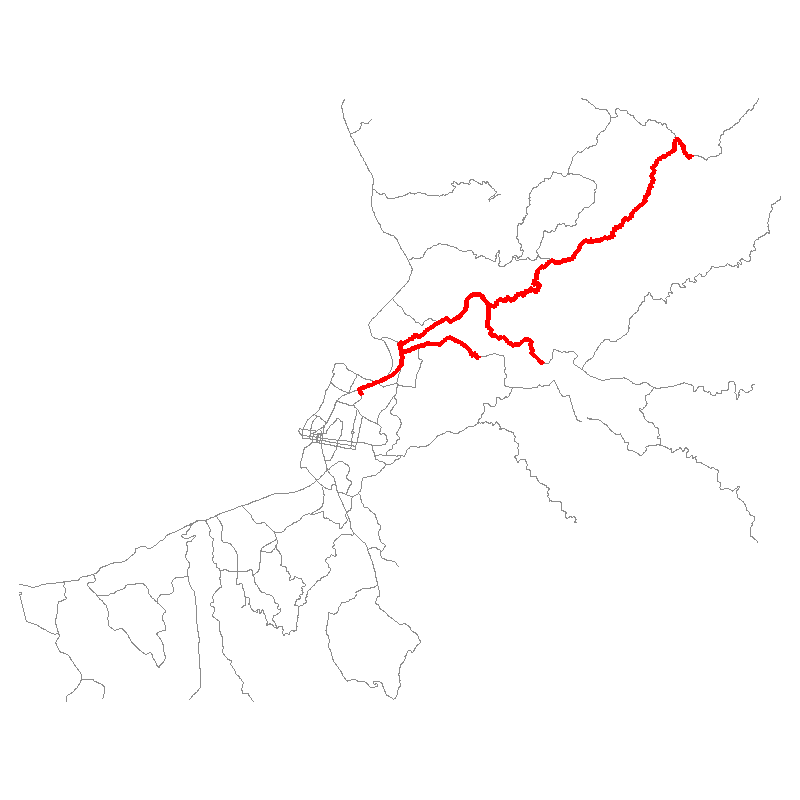

In [10]:
from IPython.display import display

if city and cfg and sampler:
    generator = validate_call(
        "Initialize RouteGenerator",
        True,
        RouteGenerator,
        city_graph=city,
        sampler=sampler
    )

    if generator:
        validate_call("Minimum Points Violation", False, generator.generate, n_points=1)
        route = validate_call("Generate Iligan Route (5 points)", True, generator.generate, n_points=5)

        if route:
            base_img = validate_call("Render base map", True, city.draw, size=800, only_drivable=True)
            context = validate_call("Bounding context", True, city.get_bounds)

            if base_img and context:
                drawn_img = validate_call(
                    "Overlay proposed route",
                    True,
                    route.draw,
                    context=context,
                    image=base_img,
                    color="#FF0000",
                    width=4
                )
                if drawn_img:
                    validate_call("Route draw square check", True, assert_square_image, drawn_img)
                    display(drawn_img)


## **TravelGraph** (in travel_graph.py)

[REJECTED] TravelGraph reject null CityGraph: Safely blocked with ValueError([TRAVEL GRAPH] CityGraph cannot be 
None.)

[REJECTED] TravelGraph reject null RouteGenerator: Safely blocked with ValueError([TRAVEL GRAPH] Must provide 
either 'routes' or 'route_generator'.)

[REJECTED] TravelGraph reject null config: Safely blocked with ValueError([TRAVEL GRAPH] Configuration dictionary 
cannot be None.)

[VALIDATED] TravelGraph initialization: Executed successfully.

[VALIDATED] TravelGraph has routes: Executed successfully.

[VALIDATED] TravelGraph has edges: Executed successfully.

[REJECTED] TravelGraph reject non-square image: Safely blocked with ValueError([TRAVEL GRAPH] Image must be 
square.)

[VALIDATED] Edge type GIF created: Executed successfully.

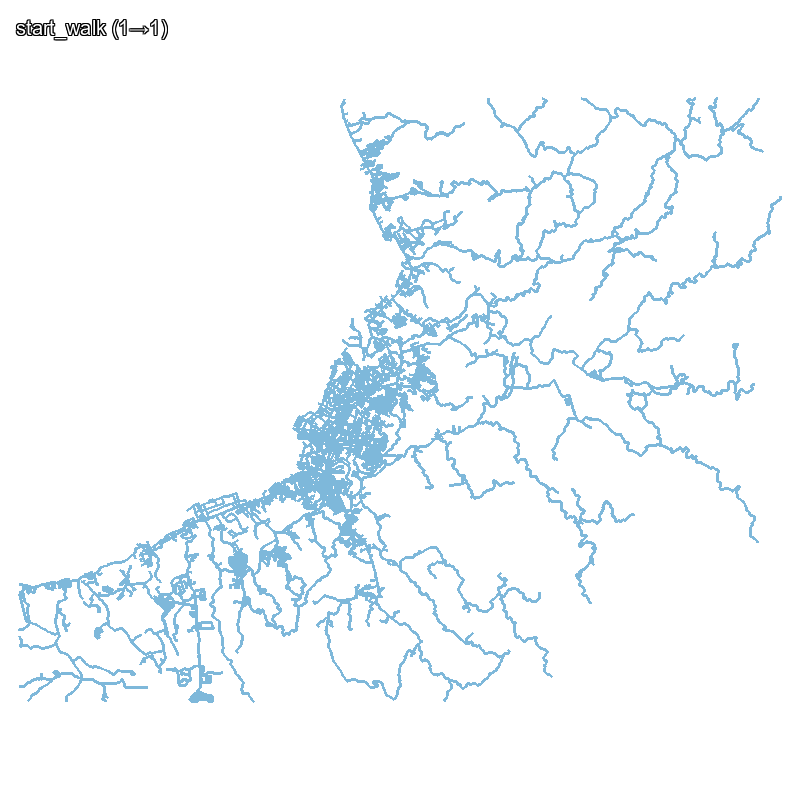

[REJECTED] findShortestJourney reject None: Safely blocked with ValueError([TRAVEL GRAPH] Start and end nodes 
cannot be None.)

Journey with ride found on attempt 1/400: Nde5ee4d4f4e14aeea1f8df747de41524 → N55735e5bf5394e868532eaf327f8dd4f

[VALIDATED] Journey with at least one ride found: Executed successfully.

Journey edge summary:

1. WA15852                | wait       | L1->L2 | edge_wt= 8.50 | cum_wt=  8.50

...

[VALIDATED] calculateJourneyDistance positive: Executed successfully.

[VALIDATED] calculateJourneyWeight positive: Executed successfully.

[VALIDATED] WA before RI in sequence: Executed successfully.

[VALIDATED] Journey terminates at layer 3: Executed successfully.

[VALIDATED] Journey GIF created: Executed successfully.

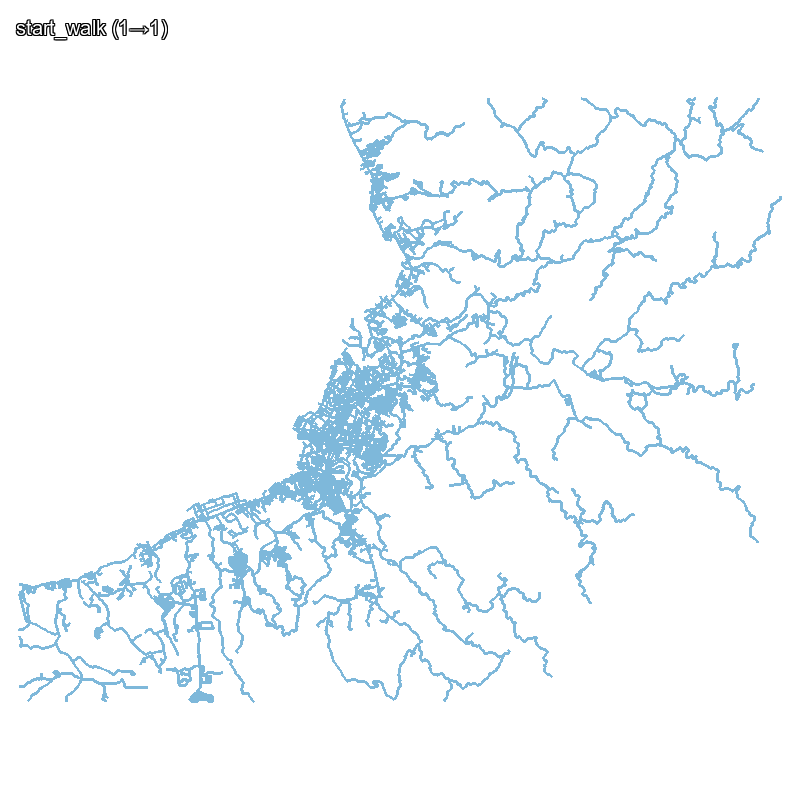

[VALIDATED] TravelGraph 3D journey render: Executed successfully.

[VALIDATED] TravelGraph 3D image dimensions valid: Executed successfully.

3D journey image size: 685x1199

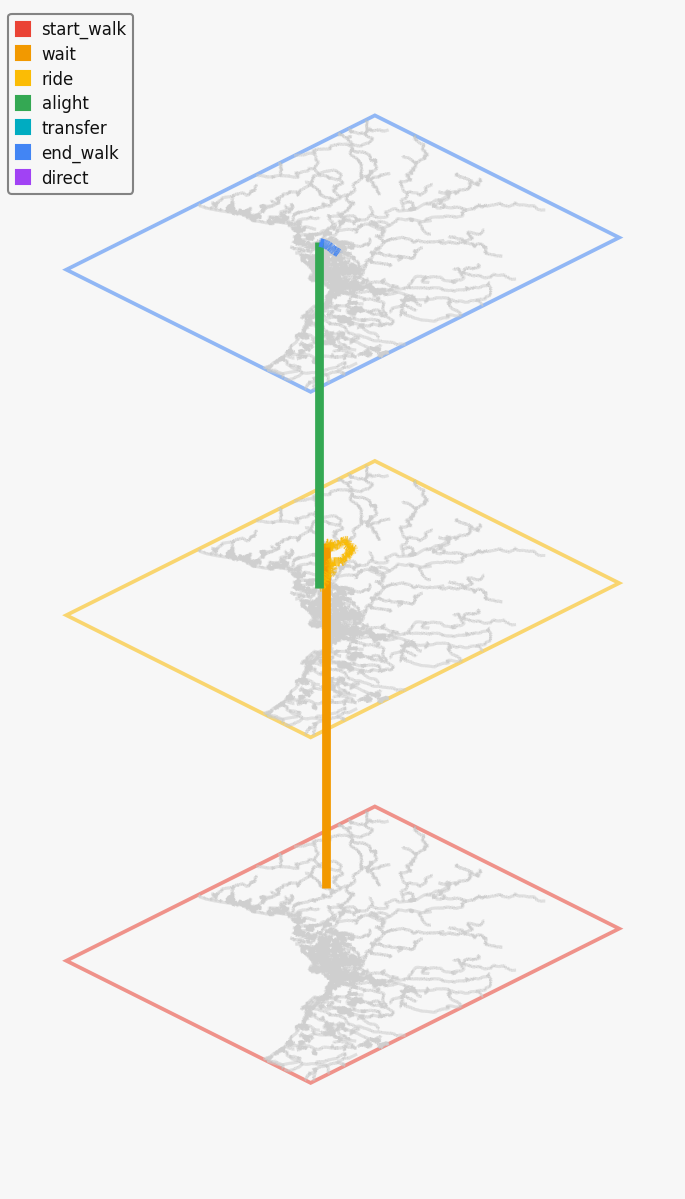

In [11]:
from utils.travel_graph import TravelGraph
from utils.visualization import draw_all, compile_to_gif
from IPython.display import Image as IPyImage, display
import os

if city and cfg and sampler and generator:
    # ── Negative: mandatory safeguards
    validate_call("TravelGraph reject null CityGraph", False, TravelGraph, cg=None, route_generator=generator, config=cfg["travel_graph"])
    validate_call("TravelGraph reject null RouteGenerator", False, TravelGraph, cg=city, route_generator=None, config=cfg["travel_graph"])
    validate_call("TravelGraph reject null config", False, TravelGraph, cg=city, route_generator=generator, config=None)

    # ── Positive: construction
    tg = validate_call(
        "TravelGraph initialization",
        True, TravelGraph,
        cg=city, route_generator=generator, config=cfg["travel_graph"],
        n_routes=20, n_points=5
    )

    if tg:
        validate_call("TravelGraph has routes", True, assert_true, len(tg.routes) > 0, "No routes generated.")
        validate_call("TravelGraph has edges", True, assert_true, len(tg.travel_graph) > 0, "No edges in travel graph.")

        # ── Negative: draw rejects non-square image
        context = city.get_bounds()
        non_square = Image.new("RGB", (800, 600), "white")
        validate_call("TravelGraph reject non-square image", False, tg.draw, context, non_square)

        base_img = city.draw(size=800, only_drivable=False)

        # ── GIF 1: Edge type showcase (one frame per type, no journey)
        EDGE_TYPES = [
            ("display_walk",     "start_walk (1→1)"),
            ("display_wait",     "wait (1→2)"),
            ("display_ride",     "ride (2→2)"),
            ("display_alight",   "alight (2→3)"),
            ("display_end_walk", "end_walk (3→3)"),
            ("display_transfer", "transfer (3→2)"),
            ("display_direct",   "direct (1→3)"),
        ]

        edge_frames = []
        for flag_name, label in EDGE_TYPES:
            frame_img = tg.draw(context, base_img, **{flag_name: True})
            frame = draw_all([], context, base_image=frame_img, resolution=800, text=label)
            edge_frames.append(frame)

        if edge_frames:
            gif_path = "utils/.cache/travel_graph_layers.gif"
            compile_to_gif(edge_frames, fps=2, export_to=gif_path)
            validate_call("Edge type GIF created", True, assert_true, os.path.exists(gif_path), "GIF not created.")
            display(IPyImage(filename=gif_path))

        # ── Journey query (forced: must include at least one ride edge for testing)
        validate_call("findShortestJourney reject None", False, tg.findShortestJourney, None, None)

        max_ride_attempts = 400
        journey = None
        start_node = None
        end_node = None

        for attempt in range(1, max_ride_attempts + 1):
            candidate_start = sampler.get_point()
            candidate_end = sampler.get_point()
            while candidate_end is candidate_start:
                candidate_end = sampler.get_point()

            candidate_journey = tg.findShortestJourney(candidate_start, candidate_end)
            if candidate_journey and any(e.id[:2] == "RI" for e in candidate_journey):
                start_node = candidate_start
                end_node = candidate_end
                journey = candidate_journey
                print(f"[bold]Journey with ride found on attempt {attempt}/{max_ride_attempts}: {start_node.id} → {end_node.id}[/bold]")
                break

        validate_call(
            "Journey with at least one ride found",
            True,
            assert_true,
            journey is not None,
            f"Could not find a journey with an RI segment after {max_ride_attempts} attempts.",
        )

        if journey:
            edge_type_names = {
                "SW": "start_walk",
                "WA": "wait",
                "RI": "ride",
                "AL": "alight",
                "TR": "transfer",
                "EW": "end_walk",
                "DI": "direct",
            }
            print("[bold cyan]Journey edge summary:[/bold cyan]")
            type_weight_totals = {}
            running_weight = 0.0

            groups = []
            for idx, e in enumerate(journey, start=1):
                prefix = e.id[:2]
                edge_weight = float(e.weight if e.weight is not None else 0.0)
                running_weight += edge_weight
                edge_type = edge_type_names.get(prefix, getattr(e, 'type', "unknown"))
                type_weight_totals[prefix] = type_weight_totals.get(prefix, 0.0) + edge_weight

                group_key = e.id.rsplit('_', 1)[0] if prefix == "RI" else prefix

                if not groups or groups[-1]["key"] != group_key:
                    groups.append({
                        "key": group_key,
                        "start_idx": idx,
                        "end_idx": idx,
                        "start_id": e.id,
                        "end_id": e.id,
                        "type": edge_type,
                        "layers": f"L{e.start.layer}->L{e.end.layer}",
                        "weight": edge_weight,
                        "cum_weight": running_weight
                    })
                else:
                    groups[-1]["end_idx"] = idx
                    groups[-1]["end_id"] = e.id
                    groups[-1]["weight"] += edge_weight
                    groups[-1]["cum_weight"] = running_weight

            for g in groups:
                idx_str = f"{g['start_idx']}" if g['start_idx'] == g['end_idx'] else f"{g['start_idx']}-{g['end_idx']}"
                id_str = f"{g['start_id']}" if g['start_id'] == g['end_id'] else f"{g['start_id']}...{g['end_id']}"
                print(
                    f"  {idx_str:>5}. {id_str:<22} | {g['type']:<10} | {g['layers']} | "
                    f"edge_wt={g['weight']:>5.2f} | cum_wt={g['cum_weight']:>6.2f}"
                )

            total_edge_weight = sum(float(e.weight if e.weight is not None else 0.0) for e in journey)
            total_edge_distance = sum(e.getLength() for e in journey if e.id[:2] in {"SW", "RI", "EW"})
            shortest_weight = tg.calculateJourneyWeight(start_node, end_node)
            shortest_distance = tg.calculateJourneyDistance(start_node, end_node)

            print("[bold cyan]Journey weights by type:[/bold cyan]")
            for prefix, wt in sorted(type_weight_totals.items()):
                print(f"  {prefix} ({edge_type_names.get(prefix, 'unknown')}): {wt:.2f}")

            print(f"[bold green]Total journey edge weight:[/bold green] {total_edge_weight:.2f}")
            print(f"[bold green]Total journey weight (A*):[/bold green] {shortest_weight:.2f}")
            print(f"[bold green]Total journey distance from edges:[/bold green] {total_edge_distance:.2f} m")
            print(f"[bold green]Total journey distance (helper):[/bold green] {shortest_distance:.2f} m")

            validate_call(
                "calculateJourneyDistance positive", True,
                assert_true, tg.calculateJourneyDistance(start_node, end_node) > 0,
                "Journey distance is zero or negative."
            )
            validate_call(
                "calculateJourneyWeight positive", True,
                assert_true, tg.calculateJourneyWeight(start_node, end_node) > 0,
                "Journey weight is zero or negative."
            )

            seg_prefixes = [e.id[:2] for e in journey]
            has_ride = "RI" in seg_prefixes
            if has_ride:
                validate_call(
                    "WA before RI in sequence", True,
                    assert_true, seg_prefixes.index("WA") < seg_prefixes.index("RI"),
                    "WA must come before RI."
                )
            validate_call(
                "Journey terminates at layer 3", True,
                assert_true, seg_prefixes[-1] in ["EW", "AL", "DI"],
                f"Journey should end with EW, AL, or DI but ends with '{seg_prefixes[-1]}'."
            )

            # ── GIF 2: Journey overlay (one frame per edge type, journey colored by edge type)
            journey_frames = []
            for flag_name, label in EDGE_TYPES:
                frame_img = tg.draw(context, base_img, journey=journey, **{flag_name: True})
                frame = draw_all([], context, base_image=frame_img, resolution=800, text=label)
                journey_frames.append(frame)

            if journey_frames:
                gif_path = "utils/.cache/journey.gif"
                compile_to_gif(journey_frames, fps=2, export_to=gif_path)
                validate_call("Journey GIF created", True, assert_true, os.path.exists(gif_path), "GIF not created.")
                display(IPyImage(filename=gif_path))

            journey_3d = validate_call(
                "TravelGraph 3D journey render",
                True,
                tg.create_3d,
                journey=journey,
                display_walk=True,
                display_wait=True,
                display_ride=True,
                display_alight=True,
                display_end_walk=True,
                display_transfer=True,
                display_direct=True,
            )
            if journey_3d:
                validate_call(
                    "TravelGraph 3D image dimensions valid",
                    True,
                    assert_true,
                    journey_3d.width > 0 and journey_3d.height > 0,
                    "3D journey image dimensions are invalid."
                )
                print(f"[bold]3D journey image size:[/bold] {journey_3d.width}x{journey_3d.height}")
                display(journey_3d)